<a href="https://colab.research.google.com/github/TranNguyenMinhQuan/BaiTapDuLieuSau/blob/main/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang chạy trên thiết bị: {device}")

Đang chạy trên thiết bị: cpu


In [2]:
# 1. Chuẩn bị transform chuẩn của bài LAB cho CIFAR-10
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_base)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_base)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# 2. Định nghĩa kiến trúc mạng gốc ban đầu
class NetBase(nn.Module):
    def __init__(self):
        super(NetBase, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Kích thước đầu vào fc1 sau 2 lần pool là 32 * 8 * 8
        self.fc1 = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.fc1(x)
        return x

model_c1 = NetBase().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_c1 = optim.SGD(model_c1.parameters(), lr=0.01, momentum=0.9)

# 3. Huấn luyện 10 epochs
print("--- CÂU 1: TIẾN HÀNH TRAIN MÔ HÌNH GỐC 10 EPOCHS ---")
for epoch in range(10):
    model_c1.train()
    correct, total = 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_c1.zero_grad()
        outputs = model_c1(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c1.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_acc = 100. * correct / total

    # Đánh giá trên tập test
    model_c1.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_c1(inputs)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    test_acc = 100. * test_correct / test_total

    print(f"Epoch [{epoch+1}/10] - Train Acc: {train_acc:.2f}% - Test Acc: {test_acc:.2f}% - Gap: {train_acc - test_acc:.2f}%")

100%|██████████| 170M/170M [00:04<00:00, 34.9MB/s]


--- CÂU 1: TIẾN HÀNH TRAIN MÔ HÌNH GỐC 10 EPOCHS ---
Epoch [1/10] - Train Acc: 46.53% - Test Acc: 56.56% - Gap: -10.03%
Epoch [2/10] - Train Acc: 60.83% - Test Acc: 62.26% - Gap: -1.43%
Epoch [3/10] - Train Acc: 65.77% - Test Acc: 65.92% - Gap: -0.15%
Epoch [4/10] - Train Acc: 68.52% - Test Acc: 66.00% - Gap: 2.52%
Epoch [5/10] - Train Acc: 70.64% - Test Acc: 67.12% - Gap: 3.52%
Epoch [6/10] - Train Acc: 71.56% - Test Acc: 68.15% - Gap: 3.41%
Epoch [7/10] - Train Acc: 72.81% - Test Acc: 69.03% - Gap: 3.78%
Epoch [8/10] - Train Acc: 73.85% - Test Acc: 69.59% - Gap: 4.26%
Epoch [9/10] - Train Acc: 74.37% - Test Acc: 68.69% - Gap: 5.68%
Epoch [10/10] - Train Acc: 74.64% - Test Acc: 69.06% - Gap: 5.58%


In [3]:
class NetWithConv3(nn.Module):
    def __init__(self):
        super(NetWithConv3, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # Thêm conv3 giữ nguyên kích thước không gian bằng padding=1
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Sau 3 lần MaxPool, kích thước ảnh từ 32x32 -> 16x16 -> 8x8 -> 4x4
        # Số lượng kênh đầu ra cuối cùng là 64 kênh
        self.fc1 = nn.Linear(64 * 4 * 4, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x))) # Thêm conv3 + pool sau conv2

        # Gợi ý debug kiểm tra shape thật: print(x.shape) trước khi qua view
        x = x.view(-1, 64 * 4 * 4)
        x = self.fc1(x)
        return x

# Khởi tạo kiểm tra thử mô hình cấu trúc mới
model_c2 = NetWithConv3().to(device)
print("\n--- CÂU 2: Khởi tạo mô hình chứa tầng Conv3 thành công! ---")
print(model_c2)


--- CÂU 2: Khởi tạo mô hình chứa tầng Conv3 thành công! ---
NetWithConv3(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1024, out_features=10, bias=True)
)



--- CÂU 3: THỬ NGHIỆM VỚI CÁC GIÁ TRỊ LEARNING RATE KHÁC NHAU ---
Đang chạy cấu hình với lr = 0.001...
  Epoch 1/5 - Loss trung bình: 1.9681
  Epoch 2/5 - Loss trung bình: 1.6568
  Epoch 3/5 - Loss trung bình: 1.4799
  Epoch 4/5 - Loss trung bình: 1.3525
  Epoch 5/5 - Loss trung bình: 1.2689
Đang chạy cấu hình với lr = 0.01...
  Epoch 1/5 - Loss trung bình: 1.4938
  Epoch 2/5 - Loss trung bình: 1.1169
  Epoch 3/5 - Loss trung bình: 0.9877
  Epoch 4/5 - Loss trung bình: 0.9112
  Epoch 5/5 - Loss trung bình: 0.8569
Đang chạy cấu hình với lr = 0.1...
  Epoch 1/5 - Loss trung bình: 1.7597
  Epoch 2/5 - Loss trung bình: 1.5988
  Epoch 3/5 - Loss trung bình: 1.5666
  Epoch 4/5 - Loss trung bình: 1.5194
  Epoch 5/5 - Loss trung bình: 1.4932


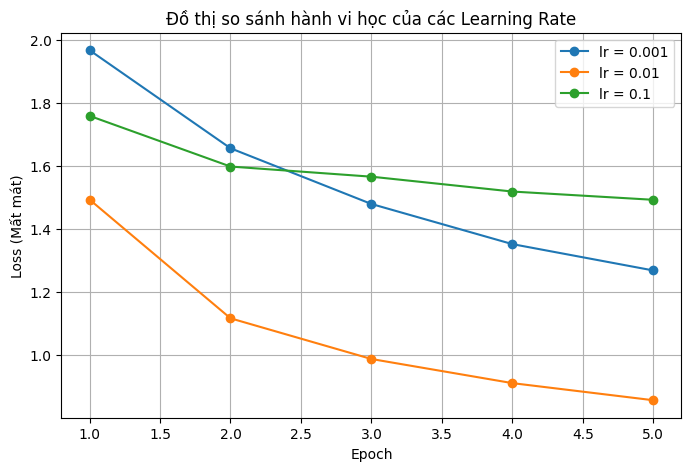

In [4]:
print("\n--- CÂU 3: THỬ NGHIỆM VỚI CÁC GIÁ TRỊ LEARNING RATE KHÁC NHAU ---")
lr_list = [0.001, 0.01, 0.1]
loss_histories = {}

for lr in lr_list:
    print(f"Đang chạy cấu hình với lr = {lr}...")
    current_model = NetBase().to(device) # Sử dụng cấu trúc mạng gốc 5 epoch
    current_optimizer = optim.SGD(current_model.parameters(), lr=lr, momentum=0.9)
    lr_losses = []

    for epoch in range(5):
        current_model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            current_optimizer.zero_grad()
            outputs = current_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            current_optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        lr_losses.append(epoch_loss)
        print(f"  Epoch {epoch+1}/5 - Loss trung bình: {epoch_loss:.4f}")

    loss_histories[lr] = lr_losses

# Vẽ đồ thị so sánh Loss của cả 3 giá trị lr
plt.figure(figsize=(8, 5))
for lr, losses in loss_histories.items():
    plt.plot(range(1, 6), losses, marker='o', label=f'lr = {lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mất mát)')
plt.title('Đồ thị so sánh hành vi học của các Learning Rate')
plt.legend()
plt.grid(True)
plt.show()


--- CÂU 4: TRỰC QUAN HÓA FEATURE MAPS TỪ CONV1 VÀ CONV2 ---


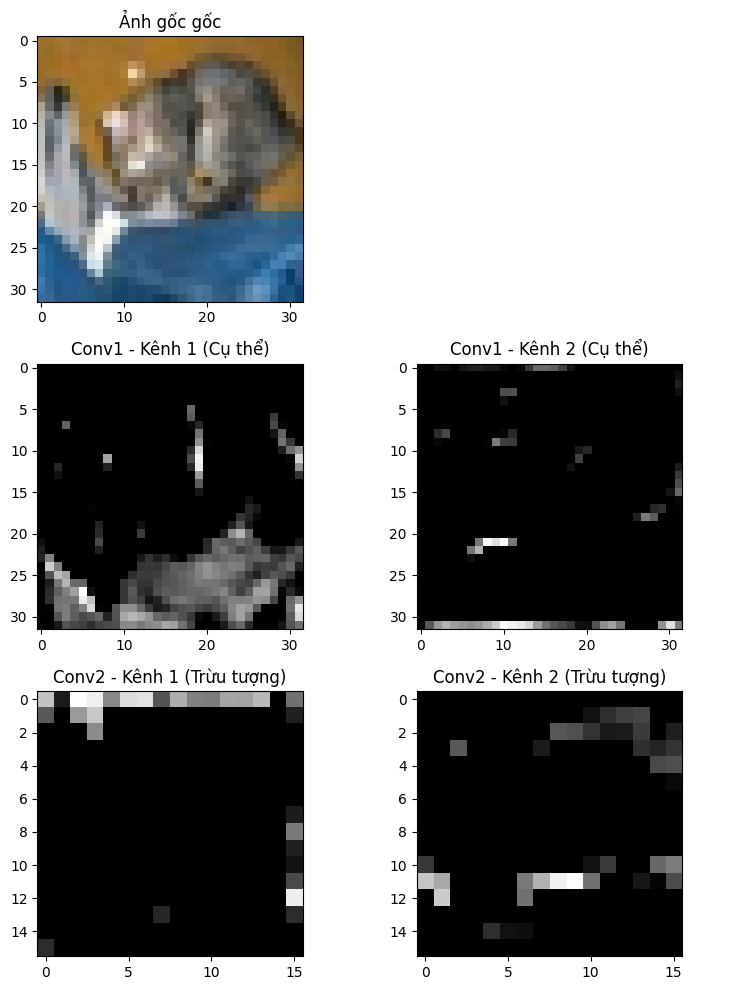

In [5]:
print("\n--- CÂU 4: TRỰC QUAN HÓA FEATURE MAPS TỪ CONV1 VÀ CONV2 ---")

# Lấy ra một bức ảnh ngẫu nhiên từ tập testloader
dataiter = iter(testloader)
images, labels = next(dataiter)
single_img = images[0].unsqueeze(0).to(device) # Thêm chiều batch_size=1 (Shape: [1, 3, 32, 32])

# Thực hiện trích xuất feature map ra ngoài class sử dụng mô hình model_c1 đã được train
model_c1.eval()
with torch.no_grad():
    h1 = torch.relu(model_c1.conv1(single_img))
    h1_pooled = model_c1.pool(h1)
    h2 = torch.relu(model_c1.conv2(h1_pooled)) # Đây chính là feature map của conv2

# Chuyển đổi định dạng tensor về dạng numpy array để vẽ bằng matplotlib
img_rgb = images[0].permute(1, 2, 0).numpy() * 0.5 + 0.5 # De-normalize ảnh gốc về [0, 1] để xem màu chuẩn
h1_np = h1.squeeze(0).cpu().numpy()
h2_np = h2.squeeze(0).cpu().numpy()

# Thiết lập layout vẽ đồ thị (ảnh gốc, 2 kênh conv1 và 2 kênh conv2)
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

# Dòng 1: Hiển thị ảnh gốc nguyên bản
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Ảnh gốc gốc")
axes[0, 1].axis('off') # Ẩn ô kế bên dòng 1

# Dòng 2: Hiển thị 2 kênh bất kỳ từ tầng conv1 (Ví dụ kênh 0 và kênh 1)
axes[1, 0].imshow(h1_np[0], cmap='gray')
axes[1, 0].set_title("Conv1 - Kênh 1 (Cụ thể)")
axes[1, 1].imshow(h1_np[1], cmap='gray')
axes[1, 1].set_title("Conv1 - Kênh 2 (Cụ thể)")

# Dòng 3: Hiển thị 2 kênh bất kỳ từ tầng conv2 (Ví dụ kênh 0 và kênh 1)
axes[2, 0].imshow(h2_np[0], cmap='gray')
axes[2, 0].set_title("Conv2 - Kênh 1 (Trừu tượng)")
axes[2, 1].imshow(h2_np[1], cmap='gray')
axes[2, 1].set_title("Conv2 - Kênh 2 (Trừu tượng)")

plt.tight_layout()
plt.show()

In [7]:
print("\n--- CÂU 5: HUẤN LUYỆN MẠNG KẾT HỢP DROPOUT VÀ DATA AUGMENTATION ---")

# 1. Thêm augmentation vào transform lúc train theo đúng đề bài yêu cầu
transform_train_augmented = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)), # Chỉ áp dụng lúc Train
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Nạp lại tập dữ liệu huấn luyện chứa cấu hình Augmentation mới
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train_augmented)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=64, shuffle=True)

# 2. Định nghĩa cấu trúc mạng nâng cao chứa Dropout (Dựa trên khung sườn mạng tầng 3 ở câu 2)
class AdvancedNet(nn.Module):
    def __init__(self):
        super(AdvancedNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Thêm tầng Dropout sau tầng pool cuối cùng và trước fc1
        self.dropout = nn.Dropout(p=0.25)
        self.fc1 = nn.Linear(64 * 4 * 4, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x))) # Pool cuối cùng trước khi vào FC

        x = x.view(-1, 64 * 4 * 4)
        x = self.dropout(x)                      # Áp dụng Dropout chặn overfitting khi train
        x = self.fc1(x)
        return x

model_c5 = AdvancedNet().to(device)
optimizer_c5 = optim.SGD(model_c5.parameters(), lr=0.01, momentum=0.9)

# 3. Tiến hành huấn luyện mô hình chống Overfitting này trong 10 Epochs
for epoch in range(10):
    model_c5.train()
    correct, total = 0, 0
    for inputs, labels in trainloader_aug: # Sử dụng dữ liệu đã Augmentation
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_c5.zero_grad()
        outputs = model_c5(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c5.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_acc = 100. * correct / total

    # Đánh giá độ chính xác trên tập Test (Lưu ý: testloader KHÔNG dùng augmentation)
    model_c5.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_c5(inputs)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    test_acc = 100. * test_correct / test_total

    print(f"Epoch [{epoch+1}/10] - Train Acc: {train_acc:.2f}% - Test Acc: {test_acc:.2f}% - Gap: {train_acc - test_acc:.2f}%")


--- CÂU 5: HUẤN LUYỆN MẠNG KẾT HỢP DROPOUT VÀ DATA AUGMENTATION ---
Epoch [1/10] - Train Acc: 35.66% - Test Acc: 45.54% - Gap: -9.88%
Epoch [2/10] - Train Acc: 48.47% - Test Acc: 55.51% - Gap: -7.04%
Epoch [3/10] - Train Acc: 54.73% - Test Acc: 62.49% - Gap: -7.76%
Epoch [4/10] - Train Acc: 58.98% - Test Acc: 65.30% - Gap: -6.32%
Epoch [5/10] - Train Acc: 61.75% - Test Acc: 68.03% - Gap: -6.28%
Epoch [6/10] - Train Acc: 63.10% - Test Acc: 68.95% - Gap: -5.85%
Epoch [7/10] - Train Acc: 64.77% - Test Acc: 69.40% - Gap: -4.63%
Epoch [8/10] - Train Acc: 65.18% - Test Acc: 69.06% - Gap: -3.88%
Epoch [9/10] - Train Acc: 66.04% - Test Acc: 70.34% - Gap: -4.30%
Epoch [10/10] - Train Acc: 66.88% - Test Acc: 71.73% - Gap: -4.85%
